# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

<hr>

## Preliminaries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from dprs import sim
from dprs.viz import Viz
from dprs.file import create_directories, export_plots

<hr>

## Simulation

In [2]:
class Parameters:
    p: float = 0.163150
    p0: float = 0.99
    seed: int = 1
    n_iterations: int = 10_000
    dim = sim.Dimension.D2
    n_x: int = 5_000
    n_y: int = 5_000
    n_z: int = 1
    edge_topology_x = sim.Topology.Periodic
    edge_topology_y = sim.Topology.Periodic
    edge_topology_z = sim.Topology.Unspecified
    edge_bc_x = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    edge_bc_y = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    edge_bc_z = (sim.BoundaryCondition.Unspecified, sim.BoundaryCondition.Unspecified)
    edge_values_x = (True, True)
    edge_values_y = (True, True)
    edge_values_z = (False, False)
    do_edge_buffering: bool = True
    processing = sim.Processing.Parallel
    sample_rate: int = 10_000
    n_threads: int = 12
parameters = Parameters()

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: list[list, list]
t_run_time: float

In [ ]:
(n_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dp(parameters)
print(f"Total number of lattice time slices = {n_lattices}\n")

The function `sim.dp` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all them concatenated into one long 1d list.

In [ ]:
raw_lattices: NDArray = np.array(raw_lattices, dtype=np.bool,) 
raw_lattices.shape

(2, 4000000)

Next, we convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [ ]:
lattices: NDArray = raw_lattices.reshape(
    n_lattices, 
    parameters.n_y, parameters.n_x,
    ).T
lattices.shape

(2000, 2000, 2)

Tracking data, which for now is the vector pair (t; mean ρ):

In [ ]:
tracking: NDArray = np.array(raw_tracking, dtype=np.float64,) 
tracking.shape

(2, 10001)

<hr>

## Visualization

In [ ]:
sim_root_name: str | None = None

In [ ]:
viz = Viz(dpi=100)
i_slice: int
name: str
title: str

Visualize the initial lattice:

In [ ]:
def make_title(parameters: Parameters, i_slice: int | None): 
    return (
        rf"$p={parameters.p:0.6f}$"
        + rf"   $s={parameters.seed}$"
        + rf"   $n_x={parameters.n_x}$"
        + rf"   $n_y={parameters.n_y}$"
        + (rf"   $i={i_slice*parameters.sample_rate:0{5}}$" 
           if i_slice is not None else "")
    )

In [ ]:
def make_name(parameters: Parameters, variable: str, i_slice: int|None = None): 
    return (
        (f"{sim_root_name}_" if sim_root_name is not None else "")
        + f"{variable}"
        + f"_p{parameters.p:0.6f}".replace(".", "p")
        + f"_s{parameters.seed}"
        + f"_nx{parameters.n_x}"
        + f"_ny{parameters.n_x}"
        + (f"_i{i_slice*parameters.sample_rate:0{5}}" 
           if i_slice is not None else "")
    )

lattice_p0p163150_s1_nx2000_ny2000_i00000


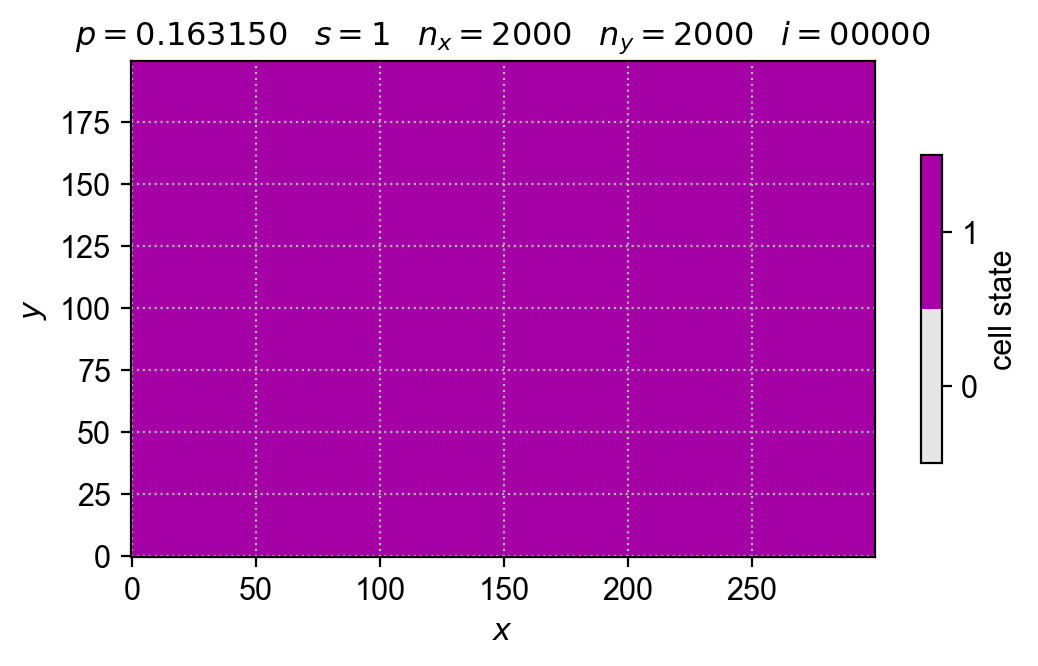

In [ ]:
i_slice = 0
name = make_name(parameters, "lattice", i_slice)
viz.image_lattice(
    name=name, 
    title=make_title(parameters, i_slice), 
    lattices=lattices, 
    p=parameters, 
    i_lattice=i_slice,
    x=300,
    y=200,
    fig_size=(6, 4,),
)
print(name)
plt.show()

Visualize the final lattice:

lattice_p0p163150_s1_nx2000_ny2000_i10000


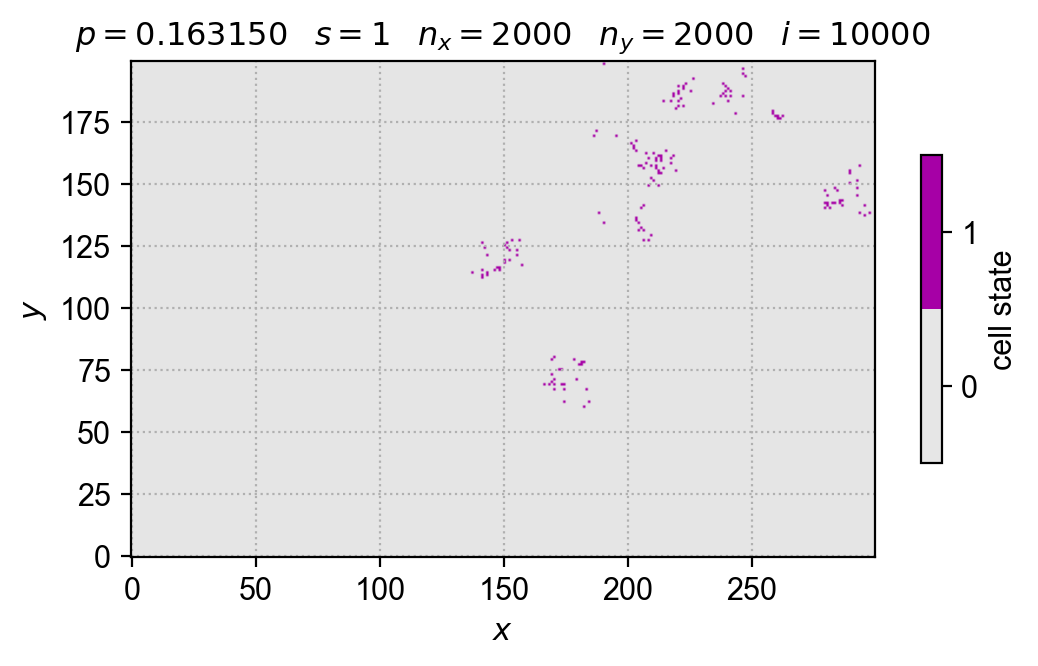

In [ ]:
i_slice = (n_lattices-1)
name = make_name(parameters, "lattice", i_slice)
viz.image_lattice(
    name=name, 
    title=make_title(parameters, i_slice), 
    lattices=lattices, 
    p=parameters, 
    i_lattice=i_slice,
    x=300,
    y=200,
    fig_size=(6, 4,),
)
print(name)
plt.show()

See Henkel et al (2008), tables 4.1 and 4.3: the decay rate of the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where $\delta \approx 0.4505$. If that's what we're seeing, there's a long "burn-in" phase. It appears we're a bit off the ideal value: (1) because there is a finite lattice-size bias; and (2) because we need to extremely precise about choosing $p=p_c$. 

Here I have heuristically tuned $p$ to
$$
    p_c =? \,\,0.163150
$$
which is rather far off any traditional critical DP probability $p_c$, probably because of the 9-cell neighborhood live/die dependency.

ρmean_p0p163150_s1_nx2000_ny2000


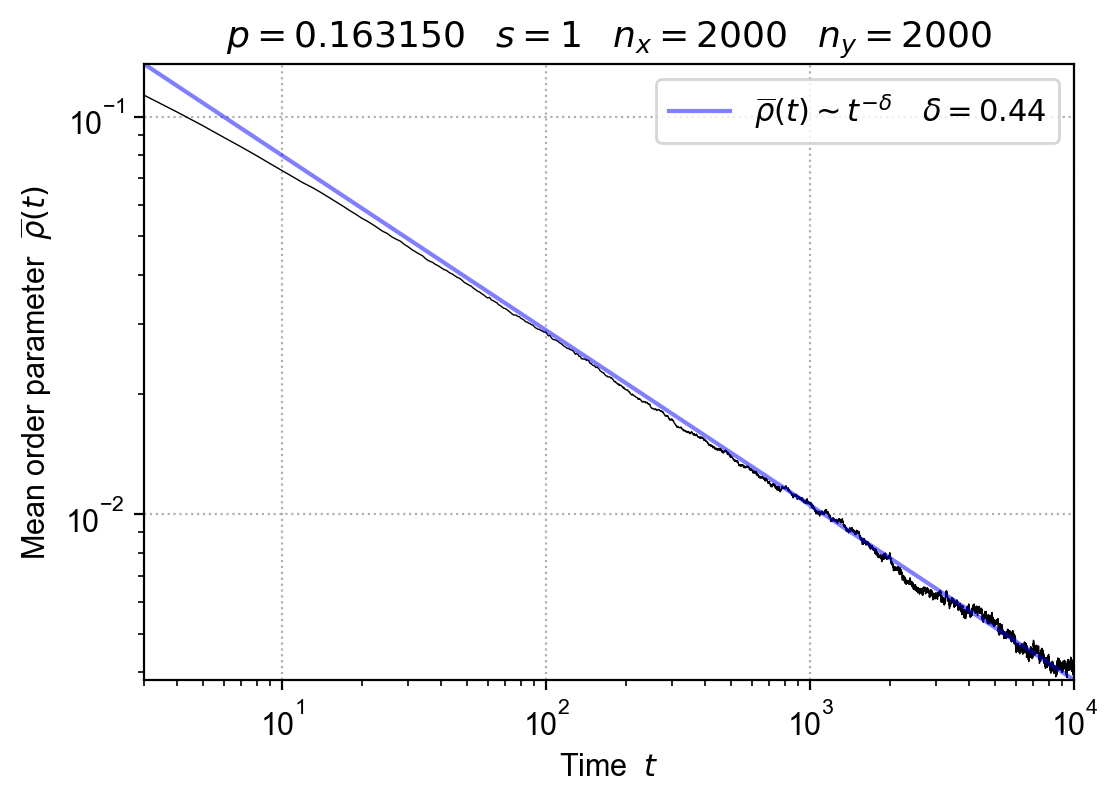

In [ ]:
δ = 0.4505
ρ_mean_ref = 0.235
δ = 0.44
ρ_mean_ref = 0.22
# δ = 0.445
# ρ_mean_ref = 0.23

name = make_name(parameters, "ρmean", None, )
title = make_title(parameters, None)
print(name)

viz.plot_ρmean(
    name,
    title,
    tracking,
    δ, 
    ρ_mean_ref,
    fig_size=(6,4,),
)

<hr>

## Export

In [ ]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp2d'